In [2]:
# Install CatBoost if not already installed (run this cell once)
!pip install catboost

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Load the PCA-reduced dataset
df = pd.read_csv('C:\\Users\\Janidu\\Documents\\PCA_Final_Output.csv')

# Display basic info
print("Dataset shape:", df.shape)
print(df.head())

# Check class balance in the target
print("\nClass distribution:")
print(df['Heart_Risk'].value_counts(normalize=True))

# Separate features and target
X = df.drop('Heart_Risk', axis=1)  # PC1 to PC17
y = df['Heart_Risk']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

Dataset shape: (70000, 18)
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -2.671386  0.694566 -0.765315 -0.413531 -1.124154  1.766144 -0.816048   
1 -1.863387  0.070991 -0.980638 -1.699887  0.949774  1.120509  0.636552   
2 -0.133402  1.041800  0.827040 -1.103121 -0.021368  0.937217 -0.278653   
3  1.563666 -0.288282  0.645432  0.269554 -0.821206  0.517196  0.100817   
4 -1.749696  2.287686 -0.503927  1.471094 -0.008833  0.248294  0.233095   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  0.543193  0.276242  0.583985 -0.063475  0.528221 -0.250724 -0.283063   
1  0.672952 -1.223475 -0.151459  0.247644  1.554454  0.003774 -1.203041   
2  0.413260 -1.587189  1.735639  1.535450  0.290514  1.266382  0.019219   
3  1.598310  1.169044 -1.023520  0.814898  0.531099  1.752706  0.161538   
4 -0.107261 -0.414100 -1.057817 -0.817415 -0.007766 -0.799231 -0.653175   

       PC15      PC16      PC17  Heart_Risk  
0  1.656887 -0.255316  0.

Baseline CatBoost Performance:
Accuracy: 0.9927142857142857
F1 Score: 0.9927059496567505
Precision: 0.9938430698739977
Recall: 0.9915714285714285
ROC AUC: 0.9994829591836734


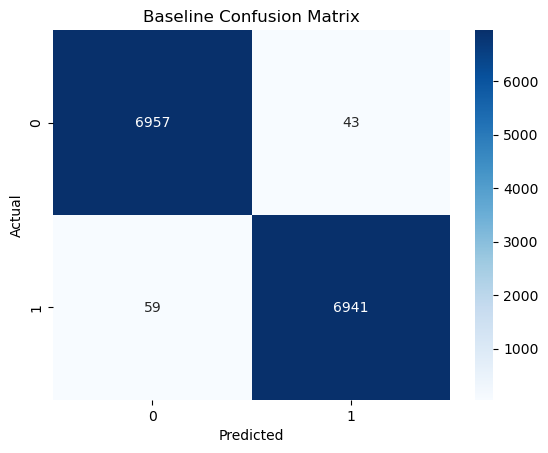

In [4]:
# Train a baseline CatBoost model (no tuning)
baseline_model = CatBoostClassifier(random_state=42, verbose=0)  # verbose=0 to suppress output
baseline_model.fit(X_train, y_train)

# Predict on test set
y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]  # For AUC

# Evaluate baseline
print("Baseline CatBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("F1 Score:", f1_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline))
print("Recall:", recall_score(y_test, y_pred_baseline))
print("ROC AUC:", roc_auc_score(y_test, y_prob_baseline))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Best hyperparameters: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.1}

Tuned CatBoost Performance:
Accuracy: 0.9927142857142857
F1 Score: 0.9927069927069927
Precision: 0.9937016890924707
Recall: 0.9917142857142857
ROC AUC: 0.9994233061224489


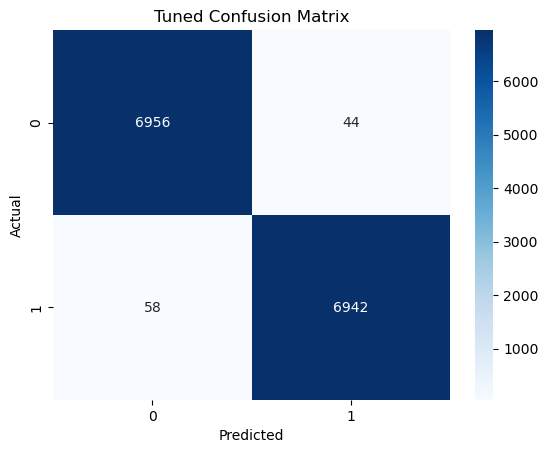


Comparison:
Baseline F1: 0.9927059496567505
Tuned F1: 0.9927069927069927


In [5]:
# Hyperparameter tuning with GridSearchCV (3 varieties as examples)
param_grid = {
    'iterations': [100, 200, 300],  # Number of boosting iterations
    'depth': [4, 6, 8],             # Tree depth
    'learning_rate': [0.01, 0.05, 0.1],  # Learning rate
    'l2_leaf_reg': [1, 3, 5]        # L2 regularization
}

grid_search = GridSearchCV(
    estimator=CatBoostClassifier(random_state=42, verbose=0),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1',  # Optimize for F1 score (good for imbalanced data)
    n_jobs=-1  # Use all CPU cores
)

grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
print("\nBest hyperparameters:", grid_search.best_params_)

# Predict with best model
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Evaluate best model
print("\nTuned CatBoost Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_prob_best))

# Confusion Matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')
plt.title('Tuned Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Compare baseline vs. tuned
print("\nComparison:")
print("Baseline F1:", f1_score(y_test, y_pred_baseline))
print("Tuned F1:", f1_score(y_test, y_pred_best))

In [6]:
import joblib
from sklearn.preprocessing import StandardScaler  # Or MinMaxScaler if used
from sklearn.decomposition import PCA

# Refit scaler and PCA on full original data for deployment
df = pd.read_csv('C:\\Users\\Janidu\\Documents\\heart_disease_risk.csv')  # Original dataset
X = df.drop('Heart_Risk', axis=1)
scaler = StandardScaler().fit(X)  # Or MinMaxScaler()
X_scaled = scaler.transform(X)
pca = PCA(n_components=0.95).fit(X_scaled)  # Your 95% variance PCA

# Save everything
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
best_model.save_model('catboost_model.cbm')  # CatBoost format

print("Model, scaler, and PCA saved successfully.")

Model, scaler, and PCA saved successfully.


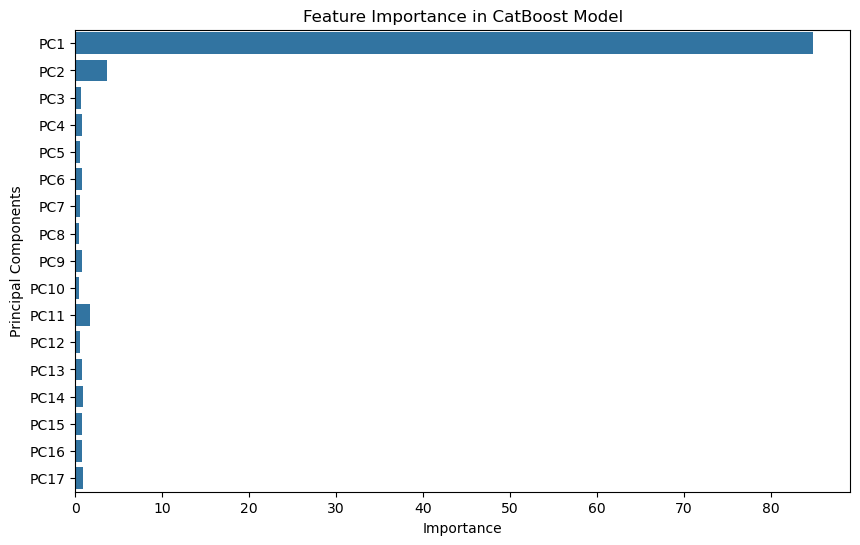

In [20]:
# Feature importance (from best model)
feature_importances = best_model.get_feature_importance()

# Define features based on PCA components (assuming 17 components from n_components=0.95)
features = [f'PC{i+1}' for i in range(len(feature_importances))]  # e.g., ['PC1', 'PC2', ..., 'PC17']

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=features)
plt.title('Feature Importance in CatBoost Model')
plt.xlabel('Importance')
plt.ylabel('Principal Components')
plt.show()